# Image Classification Project — Computer Vision (AGH)

End-to-end **classical** pipeline (no neural networks):
load → preprocess → extract features → train/tune → evaluate on a held-out test set.

Core functions live in the `cvproject` package (`src/cvproject/*.py`); this
notebook only orchestrates them and shows results. Cells marked **TODO**
depend on functions that are still boilerplate — implement them in the package,
then re-run.

> Install once from the project root: `pip install -e ".[notebook]"`

## 1. Setup

In [13]:
import numpy as np
import matplotlib.pyplot as plt

import cvproject
from cvproject import config, data, preprocessing, features, classification, metrics, viz
from cvproject.config import RNG

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(RNG)

print('cvproject', cvproject.__version__)
print('available datasets:', list(config.DATASETS))

cvproject 0.1.0
available datasets: ['potato_simple', 'potato_hard', 'apples_tomatoes']


In [14]:
# The single switch: pick the dataset to work on.
cfg = config.get_config('potato_hard')   # or 'potato_hard' / 'apples_tomatoes'
cfg['description']

'Potato leaves: early vs late blight (2000 imgs, hard).'

## 2. Load & explore

Load the images, check class balance, and preview a few samples per class.

In [15]:
if cfg['presplit']:
    X_imgs, y_str, X_test_imgs, y_test_str = data.load_presplit(cfg)
else:
    X_imgs, y_str = data.load_dataset(cfg)
    X_test_imgs = y_test_str = None

print('loaded', len(X_imgs), 'images')
import collections
print('class counts:', collections.Counter(y_str))

potato_hard/early_blight:   0%|          | 0/1000 [00:00<?, ?it/s]

potato_hard/late_blight: 100%|██████████| 1000/1000 [00:00<00:00, 1598.04it/s]

loaded 2000 images
class counts: Counter({np.str_('early_blight'): 1000, np.str_('late_blight'): 1000})


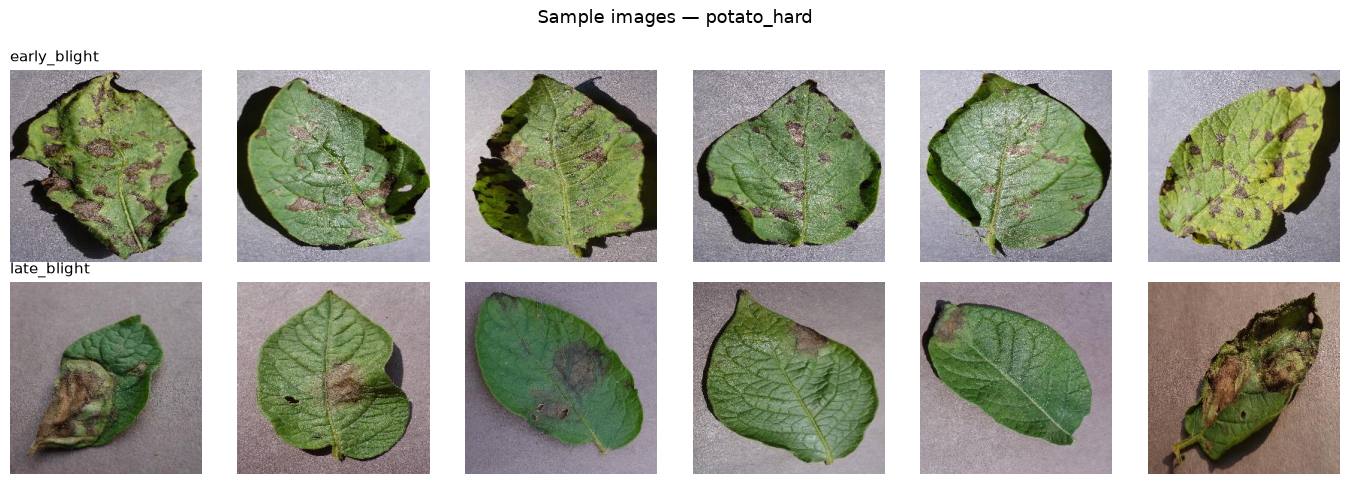

In [16]:
# Display helper (implemented): one row per class.
viz.show_class_samples(X_imgs, y_str, n_per_class=6,
                       suptitle=f"Sample images — {cfg['name']}")
plt.show()

## 3. Preprocessing

Artifact removal, brightness/colour enhancement, and segmentation of the object
from the background. **TODO:** tune the segmentation method/params for this dataset.

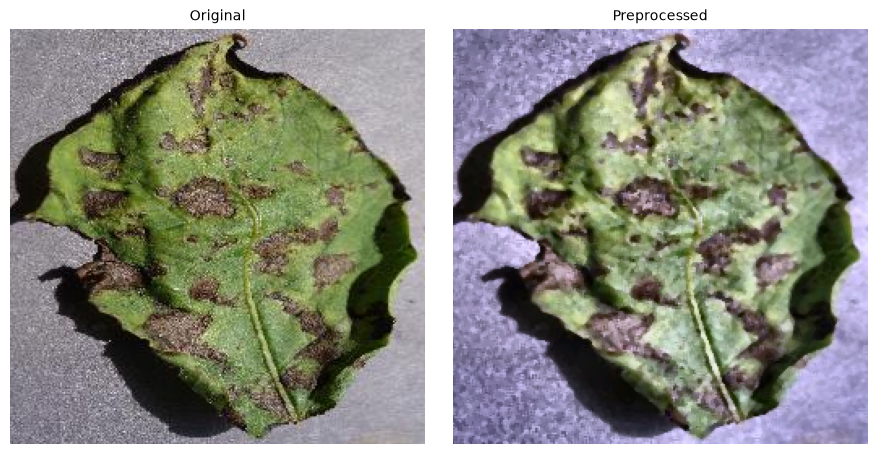

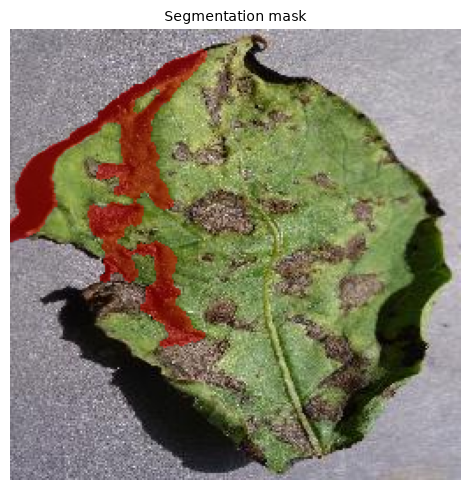

In [17]:
sample = X_imgs[0]
processed, mask = preprocessing.preprocess(sample, cfg)

viz.show_pair(sample, processed, titles=('Original', 'Preprocessed'))
plt.show()
if mask is not None:
    viz.show_mask_overlay(sample, mask, title='Segmentation mask')
    plt.show()

In [18]:
proc_imgs, masks = [], []
for img in X_imgs:
    p, m = preprocessing.preprocess(img, cfg)
    proc_imgs.append(p)
    masks.append(m)

## 4. Feature extraction

Texture (GLCM), colour statistics and shape descriptors. **TODO:** decide which
feature families help most for this dataset (`use=...`).

In [19]:
USE = ('glcm', 'color', 'shape')
X, feat_names = features.build_feature_matrix(proc_imgs, masks=masks, use=USE)
print('feature matrix:', X.shape, '|', len(feat_names), 'features')

features: 100%|██████████| 2000/2000 [00:08<00:00, 235.10it/s]

feature matrix: (2000, 85) | 85 features


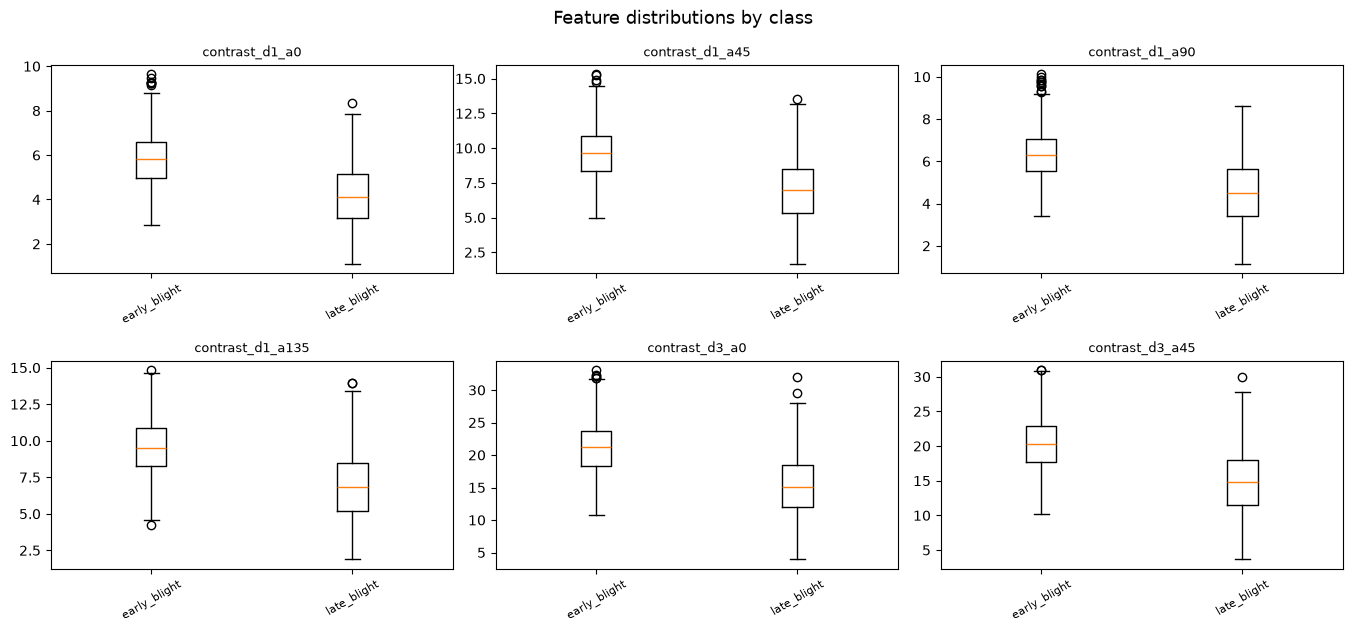

In [20]:
# Per-class feature distributions (implemented helper).
viz.plot_feature_distributions(X, y_str, feat_names, max_features=6, suptitle='Feature distributions by class')
plt.show()

## 5. Train / validation / test split

Honour the dataset's pre-split test set when present, otherwise make a stratified
three-way split.

In [21]:
y, le = data.encode_labels(y_str)

presplit = None
if cfg['presplit']:
    # TODO: extract features for the pre-split test images too, then encode.
    proc_test = [preprocessing.preprocess(im, cfg)[0] for im in X_test_imgs]
    masks_test = [preprocessing.preprocess(im, cfg)[1] for im in X_test_imgs]
    X_test, _ = features.build_feature_matrix(proc_test, masks=masks_test, use=USE)
    y_test = le.transform(y_test_str)
    presplit = (X_test, y_test)

splits = data.make_splits(X, y, val_size=0.2, test_size=0.2, presplit=presplit)
for k, v in splits.items():
    print(k, np.asarray(v).shape)

X_train (1200, 85)
y_train (1200,)
X_val (400, 85)
y_val (400,)
X_test (400, 85)
y_test (400,)


## 6. Train & tune (on train/validation)

Each model is a `StandardScaler` + classifier pipeline. **TODO:** fill in
`classification.PARAM_GRIDS` and tune on the training set.

In [22]:
models = classification.build_models()

tuned = {}
for name, model in models.items():
    grid = classification.PARAM_GRIDS.get(name, {})
    search = classification.tune(model, grid, splits['X_train'], splits['y_train'])
    tuned[name] = search.best_estimator_
    print(f'{name:15s} best CV score = {search.best_score_:.4f}  {search.best_params_}')

svm             best CV score = 0.9633  {'clf__C': 100, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}
decision_tree   best CV score = 0.8665  {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 2}
random_forest   best CV score = 0.9182  {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__n_estimators': 400}
knn             best CV score = 0.9033  {'clf__n_neighbors': 11, 'clf__weights': 'uniform'}
logreg          best CV score = 0.9475  {'clf__C': 10}


## 7. Evaluate on the held-out test set

Compare models, then inspect the best one's confusion matrix. **TODO (markdown):**
write the critical analysis of the metrics for the report.

In [23]:
preds = classification.predict_all(tuned, splits['X_test'])
comparison = metrics.compare_models(preds, splits['y_test'])
comparison

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
svm,0.9600,0.960046,0.9600,0.959999,0.960046,0.9600,0.959999
logreg,0.9400,0.940396,0.9400,0.939986,0.940396,0.9400,0.939986
random_forest,0.9150,0.915042,0.9150,0.914998,0.915042,0.9150,0.914998
knn,0.8925,0.892745,0.8925,0.892483,0.892745,0.8925,0.892483
decision_tree,0.8875,0.887975,0.8875,0.887466,0.887975,0.8875,0.887466


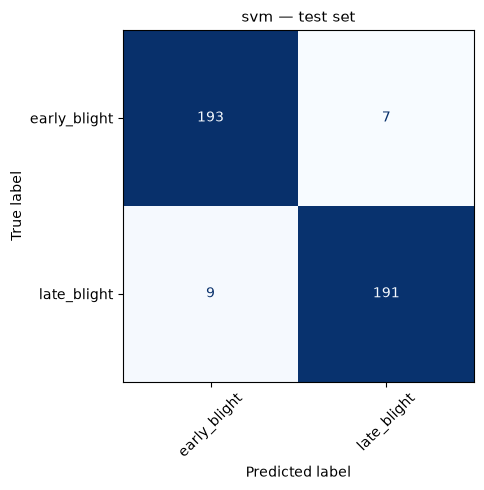

              precision    recall  f1-score   support

early_blight       0.96      0.96      0.96       200
 late_blight       0.96      0.95      0.96       200

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



In [24]:
best_name = comparison.index[0]
cm = metrics.confusion(splits['y_test'], preds[best_name])
viz.plot_confusion_matrix(cm, le.classes_, normalize=False, title=f'{best_name} — test set')
plt.show()

print(metrics.report(splits['y_test'], preds[best_name], target_names=list(le.classes_)))

## 8. Conclusions

_TODO: summarise — which features mattered, which classifier won and why,
where it fails (confusions), and any preprocessing/parameter choices worth
noting for the presentation & documentation._